# Analysing protein groups table


In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from upsetplot import UpSet
from matplotlib_venn import venn2
from matplotlib_venn import venn3

import re
from collections import Counter

plt.rcParams["font.family"] = "Arial" 

from biotite.application.clustalo import ClustalOmegaApp
import biotite.database.entrez as entrez
import biotite.sequence as seq
import biotite.sequence.graphics as graphics
import biotite.sequence.io.genbank as gb
from biotite.sequence import ProteinSequence
import biotite.sequence.io.fasta as fasta

import mpl_scatter_density 
from matplotlib.colors import LinearSegmentedColormap

from mpl_scatter_density import ScatterDensityArtist
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import scipy.stats as stats
from statannotations.Annotator import Annotator

%load_ext autoreload
from protein_inference import * 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
color_map = {
    '0': '#ffbc42',
    'VM': '#ffbc42',
    'SBM 0': '#ffbc42',
    'sbm_o_4': '#2ca02c', 
    'st':    '#d81159', 
    'Standard':    '#d81159', 
    'Unique Standard':    '#d81159',
    'sbm_3': '#73d2de', 
    'SBM 3': '#73d2de', 
    'MQ SBM 3': '#73d2de', 
    'MQ SBM 3 Percolator': '#b7e8ee', 
    'sbm3': '#73d2de',
    'Unique SBM 3': '#73d2de',
    'sbm_8': '#218380',
    'sbm8': '#218380',
    'SBM 8': '#218380', 
    'MSFragger': '#60435f', 
    'MSFragger 9nl Percolator': '#60435f', 
    'Unique MSFragger': '#60435f'
}

custom_order = ['VM', 'Standard', 'SBM 3', 'SBM 8']

# Importing the data

In [27]:
pg_sbm3 = "../SBM 3/txt/proteinGroups.txt"
pg_st = "../Standard/txt/proteinGroups.txt"
pg_0 = "../VM/txt/proteinGroups.txt"
pg_8 = "../SBM 8/txt/proteinGroups.txt"

fig_dir = '../fig_dir'
exposure = "../sites_exposure_w_FDR.txt"
f_path = "../HUMAN.fasta"
comp_file = '../human_compartment_integrated_full_filtered.tsv'

In [28]:
def process_dataframe(file_path, site_column, dataset_name):
    df = pd.read_csv(file_path, delimiter="\t")
    df = df[df['Potential contaminant'] != '+']
    df['Reverse'].fillna('-', inplace=True)
    df = df[df['Reverse'] != '+']
    df[site_column].fillna('-', inplace=True)
    df = df[df[site_column] != '-']
        
    df['SUMO2/3-DVFQQQTGG site positions'] = df[site_column]
    df['Dataset'] = dataset_name
    
    return df

df_pg_st = process_dataframe(pg_st, 'st_o_SUMO2/3-DVFQQQTGG site positions', 'Standard')
df_pg_sbm3 = process_dataframe(pg_sbm3, 'SBM_3_o_SUMO2/3-DVFQQQTGG site positions', 'SBM 3')
df_pg_0 = process_dataframe(pg_0, 'SBM_0_o_SUMO2/3-DVFQQQTGG site positions', 'VM')
df_pg_8 = process_dataframe(pg_8, 'SBM_8_o_SUMO2/3-DVFQQQTGG site positions', 'SBM 8')

pg_dfs = pd.concat([df_pg_sbm3, df_pg_st, df_pg_0, df_pg_8], ignore_index=True)

In [ ]:
%autoreload 2

pg_dfs = protein_inference_pg(pg_dfs)

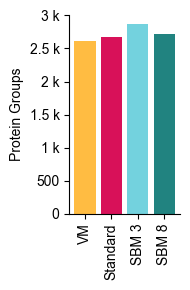

In [33]:
filtered_results_selected = pg_dfs[
    (pg_dfs['Dataset'] == "SBM 3") | 
    (pg_dfs['Dataset'] == "Standard") | 
    (pg_dfs['Dataset'] == "VM") | 
    (pg_dfs['Dataset'] == "SBM 8")
]

filtered_counts_results = filtered_results_selected.groupby('Dataset').size()
sorted_counts_pgs = filtered_counts_results.reindex(custom_order)

fig, ax = plt.subplots(figsize=(2, 3))

bars = ax.bar(
    sorted_counts_pgs.index, 
    sorted_counts_pgs.values, 
    color=[color_map.get(dataset, 'grey') for dataset in sorted_counts_pgs.index]
)

# Uncomment to display bar values on top
#for bar in bars:
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('')
ax.set_ylabel('Protein Groups')
ax.set_title('')
ax.set_xticks(range(len(sorted_counts_pgs.index)))
ax.set_xticklabels(sorted_counts_pgs.index, rotation=90)  # Adjust rotation if needed
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())

plt.tight_layout()
file_path = fig_dir + "Protein_groups.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

/Users/hmt128/miniconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_26578/582686113.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sbm_3['Intensity_log2'] = np.log2(df_sbm_3['Intensity'])
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_26578/582686113.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sbm_3['

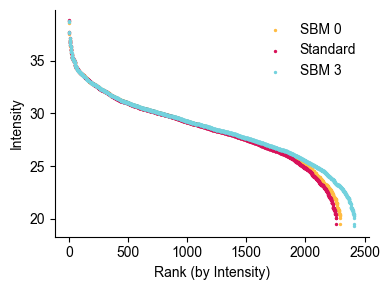

In [34]:
df_sbm_3 = pg_dfs[pg_dfs['Dataset'] == "SBM 3"]
df_st = pg_dfs[pg_dfs['Dataset'] == "Standard"]
df_0 = pg_dfs[pg_dfs['Dataset'] == "VM"]
df_0 = pg_dfs[pg_dfs['Dataset'] == "SBM 8"]

df_sbm_3['Intensity_log2'] = np.log2(df_sbm_3['Intensity'])
df_sbm_3['Rank'] = df_sbm_3['Intensity_log2'].rank(ascending=False)

df_st['Intensity_log2'] = np.log2(df_st['Intensity'])
df_st['Rank'] = df_st['Intensity_log2'].rank(ascending=False)

df_0['Intensity_log2'] = np.log2(df_0['Intensity'])
df_0['Rank'] = df_0['Intensity_log2'].rank(ascending=False)

df_sbm_3 = df_sbm_3[np.isfinite(df_sbm_3['Intensity_log2'])]
df_st = df_st[np.isfinite(df_st['Intensity_log2'])]
df_0 = df_0[np.isfinite(df_0['Intensity_log2'])]

fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(df_0['Rank'], df_0['Intensity_log2'], color=color_map["0"], s=2, label="SBM 0")
ax.scatter(df_st['Rank'], df_st['Intensity_log2'], color=color_map["st"], s=2, label="Standard")
ax.scatter(df_sbm_3['Rank'], df_sbm_3['Intensity_log2'], color=color_map["sbm3"], s=2, label="SBM 3")

ax.set_xlabel('Rank (by Intensity)')
ax.set_ylabel('Intensity')
ax.set_title('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.legend(frameon=False)
file_path = fig_dir + "dynamic_range.pdf"
plt.savefig(file_path, transparent=True)
plt.show()


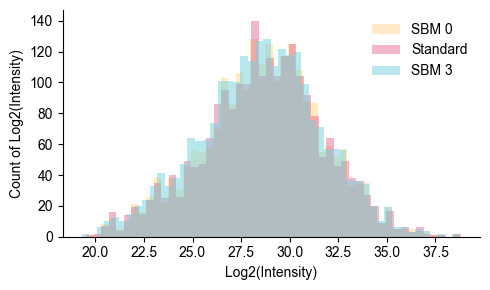

In [35]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.hist(df_0['Intensity_log2'], bins=50, color=color_map["0"], alpha=0.3, density=False, label="SBM 0")
ax.hist(df_st['Intensity_log2'], bins=50, color=color_map["st"], alpha=0.3, density=False, label="Standard")
ax.hist(df_sbm_3['Intensity_log2'], bins=50, color=color_map["sbm3"], alpha=0.5, density=False, label="SBM 3")

ax.set_xlabel('Log2(Intensity)')
ax.set_ylabel('Count of Log2(Intensity)')
ax.set_title('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(frameon=False) 
plt.tight_layout()

file_path = fig_dir + "log2_intensity_histogram.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

In [36]:

comp = pd.read_csv(comp_file, sep = '\t', header =None)
comp = comp[comp[4] >= 3]

comp[3] = comp[3].str.replace('Cytoskeleton', 'Cytosol').str.replace('Peroxisome', 'Cytosol').str.replace('Lysosome', 'Cytosol').str.replace('Endoplasmic reticulum', 'Cytosol').str.replace('Endosome', 'Cytosol').str.replace('Golgi apparatus', 'Cytosol').str.replace('Mitochondrion', 'Cytosol')

#comp[3] = comp[3].str.replace('Plasma membrane', 'Plasma membrane or Extracellular').str.replace('Extracellular space', 'Plasma membrane or Extracellular')

column_rename_map = {
    1: 'Gene_name',
    3: 'Gene Ontology (cellular component)'
}

comp.rename(columns=column_rename_map, inplace=True)

comp = comp.drop_duplicates(subset=['Gene_name', 'Gene Ontology (cellular component)'])

comp_joined = comp.groupby('Gene_name', as_index=False)['Gene Ontology (cellular component)'].apply(lambda x: ', '.join(x)).reset_index(drop=True)
comp_joined['Gene Ontology (cellular component)'] = comp_joined['Gene Ontology (cellular component)'].apply(
    lambda x: ', '.join(
        sorted(x.split(', '), key=lambda y: (y != 'Nucleus', y))
    )
)
comp_joined

,Gene_name,Gene Ontology (cellular component)
0,18S_rRNA,"Nucleus, Cytosol"
1,A1BG,"Extracellular space, Plasma membrane"
2,A1CF,"Nucleus, Cytosol"
3,A2M,"Nucleus, Cytosol, Extracellular space, Plasma ..."
4,A2ML1,Extracellular space
...,...,...
17519,hsa-miR-146a-5p,"Nucleus, Extracellular space"
17520,hsa-miR-155-5p,"Nucleus, Extracellular space"
17521,hsa-miR-21-5p,"Nucleus, Extracellular space"
17522,hsa-miR-223-3p,Extracellular space


In [37]:
dataset_names = pg_dfs['Dataset'].unique()

dataset_gene_sets = {
    name: set(pg_dfs[pg_dfs['Dataset'] == name]['Gene_name'])
    for name in dataset_names
}

all_gene_names = set().union(*dataset_gene_sets.values())

data_gns = []
for gene in all_gene_names:
    row = [gene in gene_set for gene_set in dataset_gene_sets.values()]
    row.append(gene)
    data_gns.append(row)

column_names = list(dataset_gene_sets.keys()) + ['Gene_name']
df_overlap = pd.DataFrame(data_gns, columns=column_names)
df_overlap = df_overlap.merge(comp_joined, on='Gene_name', how='left')
df_overlap['Gene Ontology (cellular component)'] = df_overlap['Gene Ontology (cellular component)'].fillna("Unknown")

df_overlap.set_index(column_names[:-1], inplace=True)

In [38]:
categories = df_overlap['Gene Ontology (cellular component)'].dropna().unique().tolist()
categories.sort() 
print(categories)

space_colors = {
    'Cytosol': '#1f77b4',
    'Cytosol, Extracellular space': '#5fa9dd',
    'Cytosol, Extracellular space, Plasma membrane': '#94c7ec',
    'Cytosol, Plasma membrane': '#bcdcf5',
    
    'Extracellular space': '#658a4c',
    'Extracellular space, Plasma membrane': '#82ad62',
    'Plasma membrane': '#98c574',
    
    'Nucleus': '#ffba08',
    'Nucleus, Cytosol': '#faa307',
    'Nucleus, Cytosol, Extracellular space': '#e85d04',
    'Nucleus, Cytosol, Extracellular space, Plasma membrane': '#dc2f02',
    'Nucleus, Cytosol, Plasma membrane': '#d00000',
    'Nucleus, Extracellular space': '#9d0208',
    'Nucleus, Extracellular space, Plasma membrane': '#6a040f',
    'Nucleus, Plasma membrane': '#370617',

    'Unknown': '#7f7f7f'
}

['Cytosol', 'Cytosol, Extracellular space', 'Cytosol, Extracellular space, Plasma membrane', 'Cytosol, Plasma membrane', 'Extracellular space', 'Extracellular space, Plasma membrane', 'Nucleus', 'Nucleus, Cytosol', 'Nucleus, Cytosol, Extracellular space', 'Nucleus, Cytosol, Extracellular space, Plasma membrane', 'Nucleus, Cytosol, Plasma membrane', 'Nucleus, Extracellular space', 'Nucleus, Extracellular space, Plasma membrane', 'Nucleus, Plasma membrane', 'Plasma membrane', 'Unknown']


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_26578/2872295872.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 200x300 with 0 Axes>

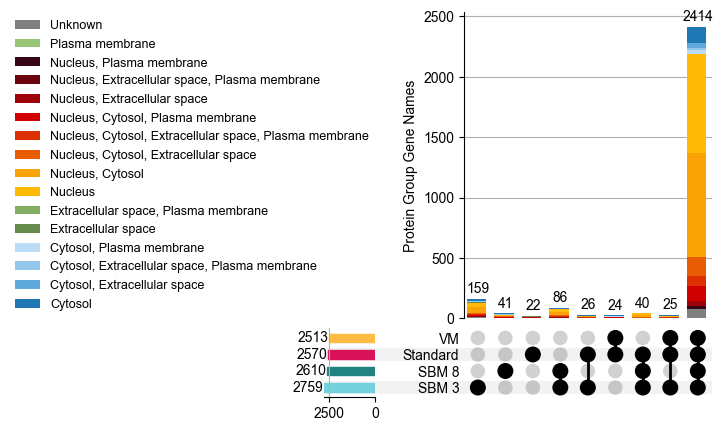

In [39]:
fig = plt.figure(figsize=(2, 3))

upset = UpSet(
    df_overlap,
    intersection_plot_elements=0,   
    subset_size="count",             
    min_subset_size=20,          
    show_counts=True,        
    element_size = 30, 
)

upset.add_stacked_bars(
    by='Gene Ontology (cellular component)',
    colors=space_colors,
    title='Protein Group Gene Names',
    elements=len(space_colors)
)

for category in color_map:  
    upset.style_categories(
        [category],
        bar_facecolor=color_map.get(category, 'grey'),  
        bar_edgecolor=None 
    )

ax_dict = upset.plot()
fig = plt.gcf()  
fig.set_size_inches(5, 5) 

for bar in ax_dict['extra0'].patches:
    bar.set_width(0.7) 
    bar.set_x(bar.get_x() - 0.15) 

ax_dict['extra0'].legend(frameon=False, loc='center', bbox_to_anchor=(-1.1, 0.5), fontsize=9)
plt.tight_layout()
plt.gcf().savefig(fig_dir + "upset_plot_gnas.pdf", format="pdf", transparent=True, bbox_inches='tight')
plt.show()